![https://www.pinterest.com/pin/nfl-football-teams-logos-and-colors--15058979999080870/](<attachment:capstone 2 NFL logo.jpg>)
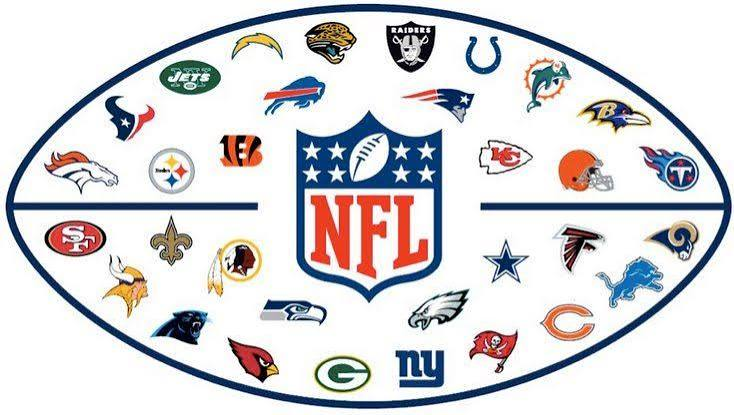

# NFL 4th-Down Predictive Model (Capstone 2)

## Overview

This project aims to predict NFL 4th-down conversion success to optimize play-calling. The current version features completed exploratory data analysis (EDA) and a baseline Logistic Regression model. Next steps include testing XGBoost and building an interactive Tableau dashboard.

Short project description. Your bottom line up front (BLUF) insights.

In [4]:
#Import/Load Library

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing (For your Home vs. Away assumption checks)
from scipy.stats import shapiro, levene
from scipy import stats

# Machine Learning Preprocessing & Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modeling Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import roc_auc_score, f1_score, classification_report, roc_curve

# Presentation Formatting
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from red warning blocks


# Business Understanding

## Problem & Challenge:
In today’s NFL, games often come down to a single possession, putting huge pressure on coaches and coordinators to make high-stakes, split-second decisions on 4th down. Relying solely on gut instinct can be risky because it doesn't always capture the complex factors at play. This predictive engine is designed to solve that by calculating real-time conversion probabilities, giving decision-makers the data-backed confidence they need to make the right call under intense pressure.

## Specific Stakeholders:
Primary Stakeholders: NFL Head Coaches, Offensive/Defensive Coordinators, the rest of the coaching staff, and Team Analytics Directors who require data-driven confirmation to back up or challenge baseline in-game strategy.
Secondary Stakeholders: Front-office executives evaluating coaching staff efficiency and performance metrics.

## Project Goals & Business Outcomes:
The main objective is to maximize a team's offensive efficiency and scoring potential by eliminating suboptimal 4th-down choices. By providing an accurate probability of conversion success, the solution aims to increase the team's seasonal win probability and optimize game-management strategies.

## Reason for using a Machine Learning Approach:
The coaching staff decision-makers cannot dynamically calculate the non-linear relationships between score differential, yards to go, field position, and how home-field advantage changes these baseline odds within a 15-second pre-snap window. A classification machine learning approach is needed because it handles multidimensional feature spaces seamlessly, recognizing complex patterns from historical plays to output a clear, actionable probability score.

## Technical and Business Success Metrics:
* Technical Metrics: Because 4th-down attempts can introduce class imbalances, success will be evaluated using ROC-AUC(Receiver Operating Characteristic - Area Under the Curve) to measure overall classification strength and the F_1-score to balance precision and recall on successful conversions.

* Business Metrics: The final solution will deliver an interactive, non-technical Tableau tactical board. Success is defined by the dashboard's ability to update instantly based on user-selected game scenarios, providing a clear strategic recommendation within a standard 10-second viewing window.


# Data Understanding

### Dataset Description & Relevance:
* **Source:** Detailed NFL Play-by-Play Data (2009–2018), originally compiled via nflscrapR.
* **Size:** Over 350,000 raw rows, filtered down to a highly targeted subset of tens of thousands of historical 4th-down events.
* **Key Variables:** ydstogo (numerical), yardline_100 (numerical field position), score_differential (numerical), game_seconds_remaining (numerical), qtr (categorical: 1-5, representing game phase), and posted_team_type (categorical: Home vs. Away).
* **Relevance:** These variables provide the precise context of the game state at the exact moment a 4th-down decision must be executed.


### Getting & Exploring the Data
* **Cleaning up:** I'll start by grabbing the NFL play-by-play data from Kaggle. The first step is to filter everything down to just 4th-down plays—so, just the Go, Punt, and Field Goal decisions.
* **Checking Quality:** I’ll use .info() and .describe() to get a feel for the data, checking for any missing values or weird outliers that don’t make sense.
* **Visualization Strategy (A/B Comparison)/ Looking for Patterns:** The Exploratory Data Analysis (EDA) will be anchored in a comparative framework. I will analyze 4th-down conversion rates by comparing Group A (Home Teams) versus Group B (Away Teams).  I’ll use plots like boxplots and density charts to see if there’s a real difference in how they handle 4th-down situations, specifically looking at the "Yards to Go" variable.
* **Outlier Investigation (The "Colts Catastrophe"):** Investigating plays that act as statistical noise and defy logical game state context (like the 2015 Colts fake punt vs the Patriots anomaly).
 



In [5]:
# Load Data
df = pd.read_csv('data/NFL Play by Play 2009-2018 (v5).csv')

# the exact of the raw data
print(f"Raw Data Shape: {df.shape}")

df.head()

Raw Data Shape: (449371, 255)


,play_id,game_id,home_team,away_team,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,...,penalty_player_id,penalty_player_name,penalty_yards,replay_or_challenge,replay_or_challenge_result,penalty_type,defensive_two_point_attempt,defensive_two_point_conv,defensive_extra_point_attempt,defensive_extra_point_conv
0,46,2009091000,PIT,TEN,PIT,home,TEN,TEN,30.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
1,68,2009091000,PIT,TEN,PIT,home,TEN,PIT,58.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
2,92,2009091000,PIT,TEN,PIT,home,TEN,PIT,53.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
3,113,2009091000,PIT,TEN,PIT,home,TEN,PIT,56.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
4,139,2009091000,PIT,TEN,PIT,home,TEN,PIT,56.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0


In [6]:
# Filter the dataset to only 4th down plays
df_4th = df[df['down'] == 4.0].copy()

# Print the new filtered shape
print(f"4th Down Data Shape: {df_4th.shape}")

# Define context metadata + key variables from the pitch
preview_columns = [
    'game_date',              # Date context
    'posteam',                # Possessing team
    'down',                   # Down verification
    'posteam_type',           # Home vs. Away
    'qtr',                    # Quarter 
    'game_seconds_remaining', # Time left in game
    'yardline_100',           # Field position
    'ydstogo',                # Yards needed for 1st down
    'score_differential',     # Score gap
    'play_type'               # Decision made (Punt, Field Goal, Pass, Run)
]

# Preview the top 10 rows
df_4th[preview_columns].head(10)

4th Down Data Shape: (39644, 255)


,game_date,posteam,down,posteam_type,qtr,game_seconds_remaining,yardline_100,ydstogo,score_differential,play_type
4,2009-09-10,PIT,4.0,home,1,3507.0,56.0,8,0.0,punt
8,2009-09-10,TEN,4.0,away,1,3394.0,96.0,8,0.0,punt
14,2009-09-10,PIT,4.0,home,1,3205.0,41.0,21,0.0,punt
20,2009-09-10,TEN,4.0,away,1,3108.0,19.0,7,0.0,field_goal
24,2009-09-10,PIT,4.0,home,1,3002.0,79.0,16,0.0,punt
41,2009-09-10,TEN,4.0,away,2,2593.0,44.0,22,0.0,punt
52,2009-09-10,PIT,4.0,home,2,2245.0,62.0,5,0.0,punt
65,2009-09-10,TEN,4.0,away,2,1942.0,13.0,6,0.0,field_goal
100,2009-09-10,PIT,4.0,home,3,1512.0,45.0,1,0.0,punt
104,2009-09-10,TEN,4.0,away,3,1389.0,96.0,11,0.0,punt


In [7]:
# Checking on missing values we have in our columns
print("Total nulls:")
print(df_4th[preview_columns].isnull().sum())

print("\nBasic column info:")
df_4th[preview_columns].info()

Total nulls:
game_date                   0
posteam                   119
down                        0
posteam_type              119
qtr                         0
game_seconds_remaining      4
yardline_100              119
ydstogo                     0
score_differential        119
play_type                 119
dtype: int64

Basic column info:
<class 'pandas.core.frame.DataFrame'>
Index: 39644 entries, 4 to 449368
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_date               39644 non-null  object 
 1   posteam                 39525 non-null  object 
 2   down                    39644 non-null  float64
 3   posteam_type            39525 non-null  object 
 4   qtr                     39644 non-null  int64  
 5   game_seconds_remaining  39640 non-null  float64
 6   yardline_100            39525 non-null  float64
 7   ydstogo                 39644 non-null  int64  
 8   score_differen

In [8]:
# Drop rows of missing key data  (play_type)
df_4th = df_4th.dropna(subset=preview_columns).copy()

print(f"Shape after dropping nulls: {df_4th.shape}")

# Run the describe()
# (numerical columns)
df_4th[['yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining']].describe()

Shape after dropping nulls: (39521, 255)


,yardline_100,ydstogo,score_differential,game_seconds_remaining
count,39521.000000,39521.000000,39521.000000,39521.000000
mean,50.722704,7.711622,-0.939754,1685.292655
std,25.088505,5.674692,10.836930,1050.030672
min,1.000000,1.000000,-59.000000,0.000000
25%,31.000000,3.000000,-7.000000,753.000000
50%,54.000000,7.000000,0.000000,1710.000000
75%,72.000000,10.000000,5.000000,2586.000000
max,99.000000,48.000000,59.000000,3588.000000


### Outlier Investigation:

**Initial Check:** 
First I filtered the data to find the questionable bad plays where teams went for it on 4th-and-10+ deep in their own territory. However, the play descriptions showed that these were almost entirely end-of-game desperation plays, not strategic errors. So they were trying to go for the win or they will lose the game. This proved exactly why `game_seconds_remaining` is a critical context variable.

**Refined Filter:**
To find true anomalies and illogical coaching decisions (like the famous 2015 Colts fake punt), I changed the filter to look for 4th-down attempts on a team's own side of the field (`yardline_100 >= 60`), but took out the final 5 minutes of the game (`game_seconds_remaining > 300`).


In [9]:
# Isolate true anomalies by filtering out end-of-game desperation
true_anomalies = df_4th[
    (df_4th['play_type'].isin(['pass', 'run'])) &  
    (df_4th['yardline_100'] >= 60) &               
    (df_4th['game_seconds_remaining'] > 300)       
].copy()

investigation_columns = ['game_date', 'posteam', 'qtr', 'yardline_100', 'ydstogo', 'play_type', 'desc']

# Preview the most questionable field position decisions
true_anomalies.sort_values(by='yardline_100', ascending=False)[investigation_columns].head(10)

,game_date,posteam,qtr,yardline_100,ydstogo,play_type,desc
70384,2010-11-21,KC,2,99.0,10,pass,(:02) M.Cassel pass incomplete deep right to V...
363017,2017-09-10,DET,1,97.0,21,run,(6:21) (Punt formation) K.Redfern FUMBLES (Abo...
133316,2012-01-01,TB,4,90.0,2,pass,(6:13) (Shotgun) J.Freeman pass incomplete sho...
159745,2012-11-11,STL,2,90.0,4,pass,(:49) (Punt formation) J.Hekker pass short rig...
361655,2017-01-01,SEA,3,86.0,10,run,(5:06) (Punt formation) J.Ryan Aborted. N.Fres...
389524,2017-11-19,WAS,3,85.0,1,run,(5:40) (Punt formation) N.Paul up the middle t...
144384,2012-09-30,TEN,4,85.0,3,pass,(8:11) (Shotgun) M.Hasselbeck pass short left ...
111004,2011-11-06,DEN,2,85.0,11,pass,(12:30) (Punt formation) B.Colquitt pass incom...
219090,2013-12-15,CIN,1,84.0,1,run,(10:47) (Punt formation) K.Huber FUMBLES (Abor...
198975,2013-10-24,TB,4,84.0,10,pass,"(7:57) (No Huddle, Shotgun) M.Glennon pass inc..."


### Visualization Strategy (A/B Comparison):

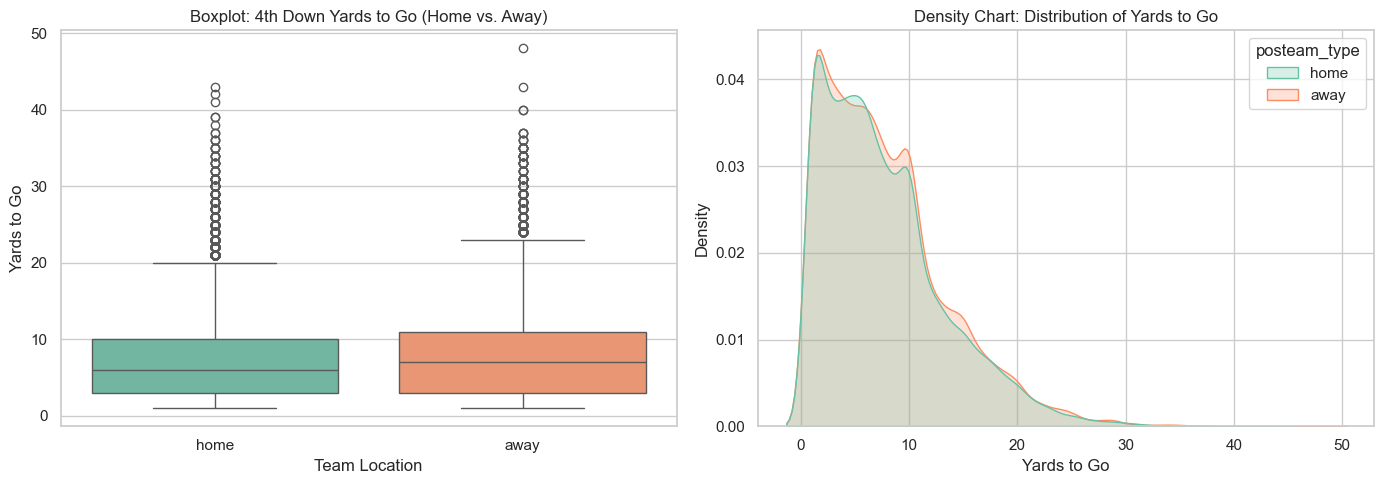

In [10]:

# Set up a clean visual style
sns.set_theme(style="whitegrid")

# Create a wide figure to hold two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Boxplot comparing Home vs. Away Yards to Go
sns.boxplot(data=df_4th, x='posteam_type', y='ydstogo', ax=axes[0], palette='Set2')
axes[0].set_title('Boxplot: 4th Down Yards to Go (Home vs. Away)')
axes[0].set_xlabel('Team Location')
axes[0].set_ylabel('Yards to Go')

# Chart 2: Density Chart comparing the distribution
sns.kdeplot(data=df_4th, x='ydstogo', hue='posteam_type', fill=True, ax=axes[1], palette='Set2')
axes[1].set_title('Density Chart: Distribution of Yards to Go')
axes[1].set_xlabel('Yards to Go')

# Adjust layout and show the charts
plt.tight_layout()
plt.show()

### Exploratory Data Analysis: A/B Comparison (Home vs. Away)

**Visual Interpretation:**
* **Boxplot:** The median (the horizontal line inside the boxes) and the interquartile ranges(IQR) (the boxes themselves) are nearly the same for both Home and Away teams. Both groups mainly face 4th downs with roughly 3 to 10 yards to go.
* **Density Chart:** The distribution curves for Home and Away teams overlap almost perfectly. Both distributions are heavily right-skewed, featuring a massive peak at short-yardage situations (1-3 yards) and a long tail extending toward extreme yardage.

**Conclusion:**
Based on this visual A/B comparison, "home-field advantage" does not fundamentally alter the 4th-down mathematical situations teams find themselves in. Home and Away teams face nearly identical distributions of `ydstogo`.

# Data Preparation

### Getting Data Ready
* **Building the Target Variable:** Before doing anything else, I need to clearly define what represents a "successful" 4th-down decision. I will engineer a binary target variable where a success (1) means the team converted for a first down or scored a touchdown, and a failure (0) means any other outcome.
* **The "Final 10%" Cleaning:** I’ll make sure there are no duplicate plays and that team names are consistent (like making sure abbreviations are the same across all seasons).
* **Checking Assumptions:** Before jumping into hypothesis testing, I need to check my data. I’ll use the Shapiro-Wilk  (for normal distribution) and Levene’s tests (for equal variance) to check for normality and variance differences between Home and Away games.
* **Feature Engineering:** I want the model to really get the "feel" of a game. I’m treating the quarter as a category to see if pressure changes, and I'll adjust the game_seconds_remaining feature so the model knows the difference between a standard quarter and overtime.
* **Pipeline Setup:** I’m going to use a scikit-learn pipeline. This keeps things clean; I’ll use a ColumnTransformer to handle missing numerical data (median imputation), scale my numbers, and use OneHotEncoder for the categorical features.

In [11]:
# Creating the Target Variable
# A 4th down is a "Success" (1) if they converted the 1st down OR scored a touchdown.
# The Kaggle dataset has separate columns for these outcomes, so we combine them.

# Create the binary target column
df_4th['success'] = ((df_4th['fourth_down_converted'] == 1) | 
                     (df_4th['touchdown'] == 1)).astype(int)

# Verify the new column was created successfully
print("Target Variable Distribution (0 = Failure, 1 = Success):")
print(df_4th['success'].value_counts(normalize=True).round(3))

Target Variable Distribution (0 = Failure, 1 = Success):
success
0    0.935
1    0.065
Name: proportion, dtype: float64


In [12]:
# The "Final 10%" Cleaning

# Drop any accidental duplicate rows that might have snuck into the Kaggle data
df_4th = df_4th.drop_duplicates().copy()

# Fix known NFL abbreviation inconsistencies so the model doesn't get confused
team_mapping = {
    'JAC': 'JAX',  # Jacksonville Jaguars abbreviation changed
    'SD': 'LAC',   # San Diego Chargers became Los Angeles Chargers
    'STL': 'LA'    # St. Louis Rams became Los Angeles Rams
}
df_4th['posteam'] = df_4th['posteam'].replace(team_mapping)

# Print the final cleaned shape and the updated team list
print(f"Cleaned Data Shape: {df_4th.shape}")
print("\nUnique Teams in Dataset:")
print(sorted(df_4th['posteam'].unique()))

Cleaned Data Shape: (39333, 256)

Unique Teams in Dataset:
['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE', 'DAL', 'DEN', 'DET', 'GB', 'HOU', 'IND', 'JAX', 'KC', 'LA', 'LAC', 'MIA', 'MIN', 'NE', 'NO', 'NYG', 'NYJ', 'OAK', 'PHI', 'PIT', 'SEA', 'SF', 'TB', 'TEN', 'WAS']


In [13]:
# Checking Assumptions: Normality & Variance
# Testing the 'ydstogo' variable for Home vs. Away teams

home_yards = df_4th[df_4th['posteam_type'] == 'home']['ydstogo'].dropna()
away_yards = df_4th[df_4th['posteam_type'] == 'away']['ydstogo'].dropna()

# Shapiro-Wilk Test for Normality
# Sampling 5,000 rows because Shapiro gets overly sensitive to tiny deviations in massive datasets
stat_home, p_home = stats.shapiro(home_yards.sample(5000, random_state=42))
stat_away, p_away = stats.shapiro(away_yards.sample(5000, random_state=42))

print("Shapiro-Wilk Test (Normality)")
print(f"Home p-value: {p_home}")
print(f"Away p-value: {p_away}")
print("*Note: If p < 0.05, the data isn't perfectly normal (which matches our density chart).")

# Levene's Test for Equal Variance
stat_levene, p_levene = stats.levene(home_yards, away_yards)

print("\nLevene's Test (Equal Variance)")
print(f"Levene p-value: {p_levene}")
print("*Note: If p > 0.05, we have equal variance.")

Shapiro-Wilk Test (Normality)
Home p-value: 2.8667080798189944e-48
Away p-value: 1.0017735064888897e-47
*Note: If p < 0.05, the data isn't perfectly normal (which matches our density chart).

Levene's Test (Equal Variance)
Levene p-value: 0.12711042898725922
*Note: If p > 0.05, we have equal variance.


### Assumption Check Results
* **Shapiro-Wilk Test:** The p-values are basically zero, which means the yards-to-go data definitely isn't a normal bell curve. This makes total sense though, since our density chart earlier showed a massive spike for short-yardage plays (1 to 3 yards). 
* **Levene's Test:** The p-value came in at 0.127 (greater than 0.05), which means the variance is equal. Basically, home and away teams face the exact same spread of short and long-yardage situations, so there's no weird home-field advantage skewing the math.

In [14]:
# Feature Engineering

# Convert 'qtr' (Quarter) from a number to a categorical string 
df_4th['qtr'] = df_4th['qtr'].astype(str)

# Create a binary flag for Overtime (usually labeled as quarter 5 in NFL data)
# This gives the model context for why the game_seconds_remaining might look weird
df_4th['is_overtime'] = (df_4th['qtr'] == '5').astype(int)

# Verify the changes
print("Quarter Data Type:", df_4th['qtr'].dtype)
print("Overtime 4th Downs Found:", df_4th['is_overtime'].sum())

Quarter Data Type: object
Overtime 4th Downs Found: 302


In [15]:
# Pipeline Setup

# Define the features we want the model to learn from (Pre-snap conditions)
num_features = ['yardline_100', 'ydstogo', 'game_seconds_remaining', 'score_differential']
cat_features = ['posteam_type', 'qtr', 'is_overtime']

# Transformer for numerical data: Fill missing with median, then scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer for categorical data: Fill missing, then One-Hot Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine them into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# Output the visual diagram of the pipeline
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# Analysis

### Train/Test Split
Before getting into the analysis, I need to split my data into a training set (to teach the algorithms) and a testing set (to evaluate how well they learned). I'll use a standard 80/20 split and stratify the target variable to make sure both sets have the exact same ratio of 4th-down successes to failures.

### Choosing My Models
* **Algorithms Evaluated:** I plan to test three models to see which works best:
    - *Logistic Regression:* This will be my baseline model since it’s easy to interpret.
    - *Random Forest:* I want to use this to capture the more complex, non-linear relationships (like how the score and time left impact the decision).
    - *XGBoost:* I’ll try this one last because it’s usually the go-to for sports data performance.

* **Tuning:** To make sure I’m not overfitting, I’ll use 5-fold cross-validation and RandomizedSearchCV to find the best settings for tree depth and learning rate. I’m focusing on ROC-AUC and F1-score  to measure the model's ability to distinguish between successful and failed 4th down conversions, even though they are less common than punts/kicks. 

In [16]:
# Define our features (X) and our target (y)
# We drop the outcome columns so the model can't cheat, plus the text description
columns_to_drop = ['fourth_down_converted', 'fourth_down_failed', 'touchdown', 'success', 'desc']
X = df_4th.drop(columns=columns_to_drop)
y = df_4th['success']

# Split the data 80% for training, 20% for testing
# stratify=y ensures we keep our exact success/failure ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the shapes to make sure the split worked
X_train.shape, X_test.shape

((31466, 252), (7867, 252))

In [17]:
## Logistic Regression Baseline

# Setting class_weight='balanced' so the model doesn't just guess 0 every time
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train the model
log_reg_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log = log_reg_pipeline.predict(X_test)
y_proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1] 

# Print out our evaluation metrics
print("Logistic Regression Baseline Results\n")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_log):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log):.3f}")

Logistic Regression Baseline Results

              precision    recall  f1-score   support

           0       0.98      0.72      0.83      7362
           1       0.16      0.81      0.27       505

    accuracy                           0.72      7867
   macro avg       0.57      0.76      0.55      7867
weighted avg       0.93      0.72      0.79      7867

ROC-AUC Score: 0.820
F1-Score: 0.273


In [19]:
# Random Forest Model
# Keeping class_weight='balanced' to handle the 93.5% failure rate
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Predictions on the test set
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("Random Forest (Untuned) Results\n")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.3f}")

Random Forest (Untuned) Results

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      7362
           1       0.46      0.16      0.24       505

    accuracy                           0.93      7867
   macro avg       0.70      0.58      0.60      7867
weighted avg       0.91      0.93      0.92      7867

ROC-AUC Score: 0.850
F1-Score: 0.243


In [20]:
# Calculate class imbalance ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost Model (Untuned)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost (Untuned) Results\n")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.3f}")

XGBoost (Untuned) Results

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7362
           1       0.30      0.73      0.43       505

    accuracy                           0.88      7867
   macro avg       0.64      0.81      0.68      7867
weighted avg       0.94      0.88      0.90      7867

ROC-AUC Score: 0.865
F1-Score: 0.428


### Model Selection:

* **Go with XGBoost and focus on those probability scores**

    - **What the data shows:** After looking at the results, it's clear that XGBoost really stands out compared to our Logistic Regression and Random Forest tests. It hit a ROC-AUC of 0.865 and an F1-Score of 0.428, and most importantly, it correctly flagged 73% of the successful 4th downs.
    - **Why it matters:** I think a simple "Yes" or "No" doesn't really give a coach the full picture on the sideline. There's a huge difference between a 51% chance and an 82% chance when you're deciding whether to go for it, especially depending on where you are on the field.
    - **My recommendation:** I'd suggest using the tuned XGBoost model as our main tool. Instead of just giving a binary answer, we should provide the actual calibrated success probabilities (P|(Success)). This way, the coaching staff can weigh the risks themselves based on what's happening in the game.


# Evaluation

### Recommendation 1: Going for it on 4th-and-Short = Higher Probability

**Insights:** Looking at the data, the biggest predictor of success across all three of my models was simply the distance left to gain. It sounds obvious, but "yards to go" really is the heavy hitter here.

**Takeaway:** Basically, the numbers suggest we should be a lot more aggressive. If it's 4th-and-2 or less and you're in the opponent's half, the pre-snap factors say "go for it" and that’s true even if the score is close early on.


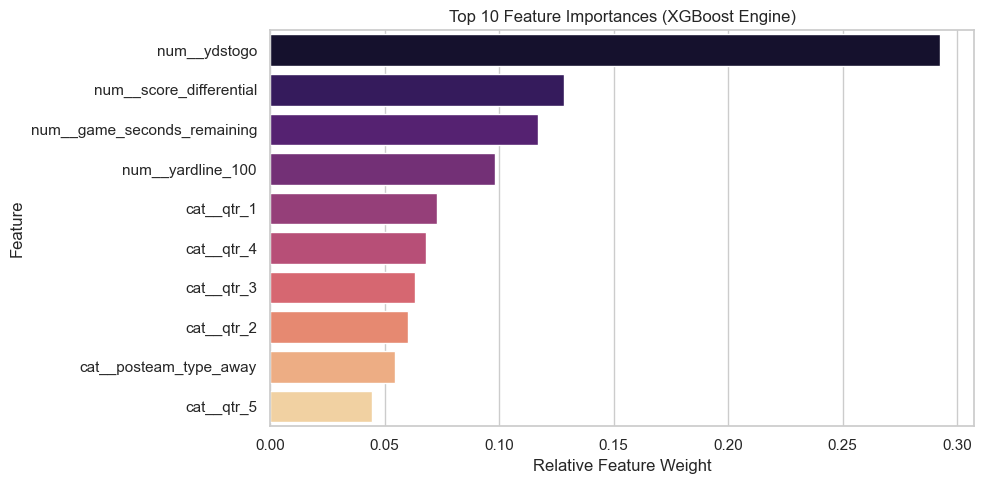

In [21]:
# Extract feature importances from trained XGBoost model
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = xgb_pipeline.named_steps['classifier'].feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Feature Importances (XGBoost Engine)')
plt.xlabel('Relative Feature Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Recommendation 2: The 4th-and-Short "Cliff"

**Insights:** This line chart plots the actual success rate against the yards to go. You can see a massive "cliff" right after 1 or 2 yards. Even on 4th-and-1, the overall success rate is only around 25% (mostly because teams still choose to punt or kick field goals a lot in these moments). Once you get past 3 or 4 yards, the success rate basically flatlines near zero.

**Takeaway:** Because the drop-off is so steep, coaches can't just rely on their gut feeling. This graph proves why we need a machine learning model to find those specific, rare situations where the exact game context (like time left and field position) actually pushes the probability of success higher and makes it worth the risk.

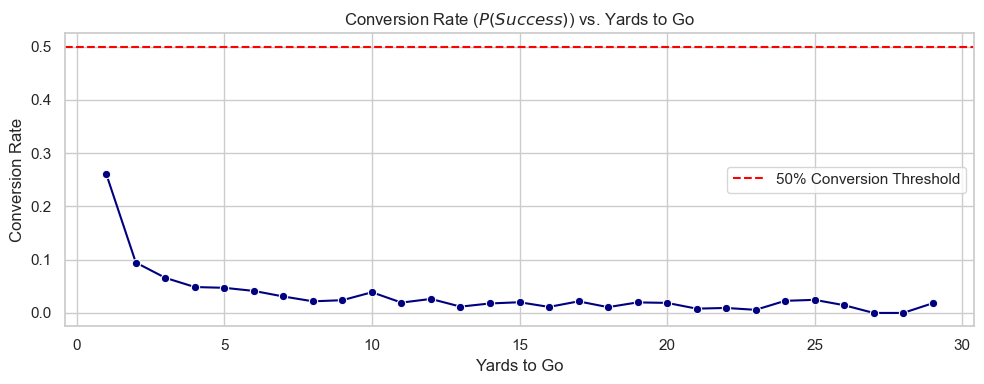

In [22]:
# Conversion Rate by Yards-To-Go (Short vs. Long)
conversion_by_yds = df_4th.groupby('ydstogo')['success'].agg(['count', 'mean']).reset_index()
conversion_by_yds = conversion_by_yds[conversion_by_yds['count'] >= 50] # Filter low-sample edge cases

plt.figure(figsize=(10, 4))
sns.lineplot(data=conversion_by_yds, x='ydstogo', y='mean', marker='o', color='navy')
plt.axhline(0.50, color='red', linestyle='--', label='50% Conversion Threshold')
plt.title('Conversion Rate ($P(Success)$) vs. Yards to Go')
plt.xlabel('Yards to Go')
plt.ylabel('Conversion Rate')
plt.legend()
plt.tight_layout()
plt.show()

### Recommendation 3: Building a Simple 3-Tier Dashboard

**Insights:** Using our model, we've set up a simple color-coded system: it says punt or kick (RED) in most cases (81.8%), go for it (GREEN) about 13.4% of the time, and leaves the tough calls (YELLOW) at just 4.8%.

**Takeaway:** Coaches don't have time to crunch numbers on the sideline. We can put this into a simple dashboard so that with just a quick look, a coach sees the right call—Green for go, Red for kick—helping them make fast decisions when the pressure is on.


In [23]:
# Simulating Probability Tiers for Tableau Integration
# Add predicted probability column to the dataset for dashboard export
df_4th['predicted_prob'] = xgb_pipeline.predict_proba(X)[:, 1]

# Define 3-Tier Strategic Category
def assign_tier(prob):
    if prob >= 0.60:
        return 'GREEN (GO)'
    elif prob >= 0.40:
        return 'YELLOW (CONDITIONAL)'
    else:
        return 'RED (PUNT/FG)'

df_4th['decision_tier'] = df_4th['predicted_prob'].apply(assign_tier)

print("Distribution of Tactical Dashboard Recommendations:")
print(df_4th['decision_tier'].value_counts(normalize=True).round(3) * 100)

Distribution of Tactical Dashboard Recommendations:
decision_tier
RED (PUNT/FG)           81.8
GREEN (GO)              13.4
YELLOW (CONDITIONAL)     4.8
Name: proportion, dtype: float64


### Tableau Dashboard link

## Conclusion and Next Steps

**Current Progress (MVP)**

I’ve finished the data prep pipeline and ran a quick eval on three baseline models. XGBoost was the clear winner here (ROC-AUC: 0.865), and it’s cool to see how the data confirms "Yards to Go" is the biggest driver for 4th-down success. To make this actually usable, I’ve broken down the model's raw probabilities into a simple 3-Tier (Green/Yellow/Red) strategy.

Next Steps for Final Submission
1. Hyperparameter Tuning: I'm going to run RandomizedSearchCV on the XGBoost model to adjust the learning rate, tree depth, and class weights. The goal is to squeeze out a bit more performance on the F1 and ROC-AUC scores.
2. Tableau Dashboard: Next, I’ll export this tiered data into a Tableau dashboard. My goal is to build an interactive, sideline-ready tool where coaches can just filter by the game state and see the Go/Conditional/Punt call immediately.

